# **Music Genre Classification**
This project focuses on classifying music genres from audio clips using deep learning. The audio signals are first converted into mel-spectrograms, which allow the models to learn patterns in both time and frequency. Multiple models, including a CNN built from scratch and pretrained architectures like EfficientNet and ResNet, are trained and compared. Finally, their predictions are combined using an ensemble approach to improve overall performance.

# **1. Imports & Configs**

In [116]:
import importlib, subprocess, sys

for pkg in ['wandb', 'transformers']:
    if importlib.util.find_spec(pkg) is None:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

print('Dependencies ready.')

Dependencies ready.


In [117]:
import os
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import timm
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from tqdm import tqdm
import wandb
from kaggle_secrets import UserSecretsClient


SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)


DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

#  PATHS 
BASE_DIR    = '/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup'
STEMS_DIR   = os.path.join(BASE_DIR, 'genres_stems')
MASHUPS_DIR = os.path.join(BASE_DIR, 'mashups')
ESC_DIR     = os.path.join(BASE_DIR, 'ESC-50-master', 'audio')
TEST_CSV    = os.path.join(BASE_DIR, 'test.csv')

# LABEL MAPPINGS
GENRES    = sorted(['blues','classical','country','disco','hiphop','jazz','metal','pop','reggae','rock'])
GENRE2IDX = {g: i for i, g in enumerate(GENRES)}
IDX2GENRE = {i: g for g, i in GENRE2IDX.items()}

# WANDB 
# secrets   = UserSecretsClient()
# wandb_key = secrets.get_secret("wandb_api_key")
# print("Key length:", len(wandb_key))
# wandb.login(key=wandb_key)

print(f'Genres: {GENRES}')
print('Setup complete ✅')

Device: cuda
Genres: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
Setup complete ✅


In [118]:
#import wandb 
#wandb.login()

In [119]:
MODEL_DIR = "/kaggle/input/models/arsh1ya/trained-models/other/default/1"

X_PATH     = os.path.join(MODEL_DIR, 'X_train_data.npy')
Y_PATH     = os.path.join(MODEL_DIR, 'y_train_data.npy')

X = np.load(X_PATH)
y = np.load(Y_PATH)
print("X shape:", X.shape)
print("y shape:", y.shape)

cnn_ckpt    = os.path.join(MODEL_DIR, "cnn_scratch_final.pth")
enet_ckpt   = os.path.join(MODEL_DIR, "enet_best (1).pth")
resnet_ckpt = os.path.join(MODEL_DIR, "resnet50_final.pth")

import torch.nn as nn

class CNN(nn.Module):
    def __init__(self, n_classes=10):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64,128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*16*64, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, n_classes)
        )

    def forward(self, x):
        return self.fc(self.conv(x))

cnn = CNN()
cnn.load_state_dict(torch.load(cnn_ckpt, map_location=DEVICE))
cnn = cnn.to(DEVICE)
cnn.eval()
print("CNN loaded ✅")


enet = timm.create_model('efficientnet_b3', pretrained=False, num_classes=10)
enet.load_state_dict(torch.load(enet_ckpt, map_location=DEVICE))
enet = enet.to(DEVICE)
enet.eval()
print("EfficientNet-B3 loaded ✅")


resnet = models.resnet50(pretrained=False)
resnet.fc = nn.Linear(resnet.fc.in_features, 10)

resnet.load_state_dict(torch.load(resnet_ckpt, map_location=DEVICE))
resnet = resnet.to(DEVICE)
resnet.eval()
print("ResNet50 loaded ✅")

X shape: (27000, 128, 512)
y shape: (27000,)
CNN loaded ✅
EfficientNet-B3 loaded ✅
ResNet50 loaded ✅


# **2.   Exploratory Data Analysis (EDA)**

## 2.1 **Class Distribution**

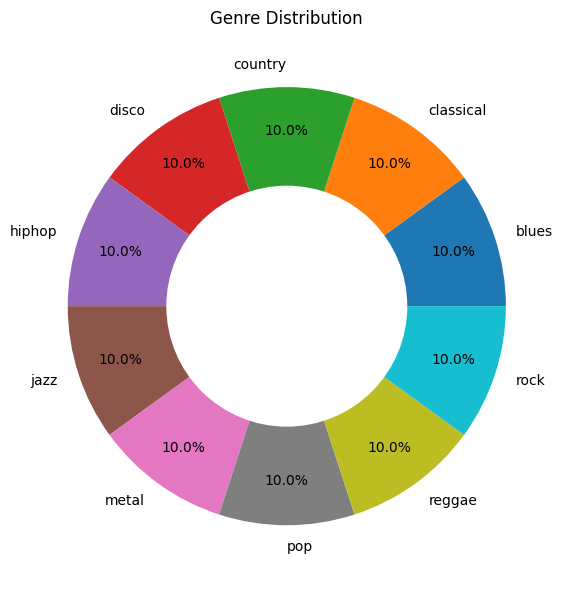

In [120]:
counts = np.bincount(y)

plt.figure(figsize=(6,6))
wedges, texts, autotexts = plt.pie(
    counts,
    labels=GENRES,
    autopct='%1.1f%%',
    pctdistance=0.8
)

# donut hole
centre = plt.Circle((0,0), 0.55, fc='white')
plt.gca().add_artist(centre)

plt.title("Genre Distribution")
plt.tight_layout()
plt.show()

The dataset is fairly balanced across genres, which helps prevent bias during training.

## 2.2 **Spectrogram Visualization**

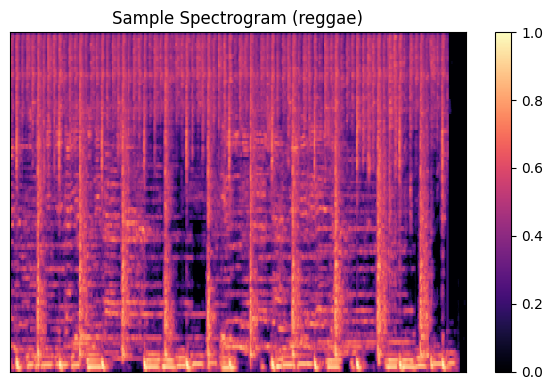

In [121]:
idx = np.random.randint(0, len(X))

plt.figure(figsize=(6,4))
librosa.display.specshow(X[idx], sr=22050, hop_length=512)
plt.title(f"Sample Spectrogram ({GENRES[y[idx]]})")
plt.colorbar()
plt.tight_layout()
plt.show()

The values are normalized between 0 and 1, which ensures stable training and avoids numerical issues.

## 2.3 **Genre-wise Comparison**

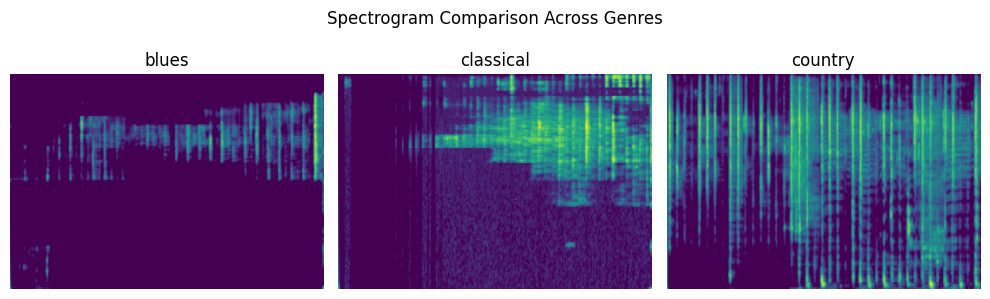

In [122]:
plt.figure(figsize=(10,3))

for i in range(3):
    idx = np.where(y == i)[0][0]  # pick one sample per genre
    plt.subplot(1,3,i+1)
    plt.imshow(X[idx], aspect='auto', origin='lower')
    plt.title(GENRES[i])
    plt.axis('off')

plt.suptitle("Spectrogram Comparison Across Genres")
plt.tight_layout()
plt.show()

Different genres show distinct frequency patterns, indicating that spectrogram-based models can effectively learn discriminative features.

## 2.4 **Variance Map**

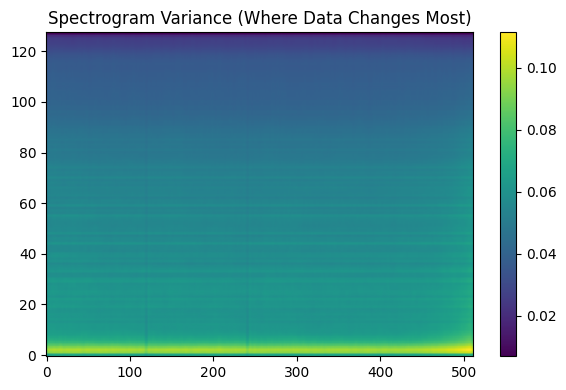

In [123]:
var_map = X.var(axis=0)

plt.figure(figsize=(6,4))
plt.imshow(var_map, aspect='auto', origin='lower')
plt.title("Spectrogram Variance (Where Data Changes Most)")
plt.colorbar()
plt.tight_layout()
plt.show()

High-variance regions indicate where most information lies, helping the model focus on meaningful frequency-time regions.

# **3.    Preprocessing**
In this step, raw audio files are converted into mel-spectrograms, which are more suitable for training deep learning models. Additional techniques like normalization and multi-crop extraction are applied to make the data more consistent and informative.

In [124]:
# def _normalize(x):
#     return (x - x.min()) / (x.max() - x.min() + 1e-6)

# def _mel_to_crops(mel_db, max_frames=512):
#     T = mel_db.shape[1]

#     if T <= max_frames:
#         pad = np.pad(mel_db, ((0,0),(0, max_frames - T)))
#         norm = _normalize(pad)
#         return [norm, norm, norm]

#     mid = (T - max_frames)//2

#     segments = [
#         mel_db[:, :max_frames],
#         mel_db[:, mid:mid+max_frames],
#         mel_db[:, -max_frames:]
#     ]

#     return [_normalize(s) for s in segments]

# def extract_melspectrogram_multicrop(file_path, sr=22050, n_mels=128):
#     y, _ = librosa.load(file_path, sr=sr)
#     mel  = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels, hop_length=512)
#     mel_db = librosa.power_to_db(mel, ref=np.max)
#     return _mel_to_crops(mel_db)

# def extract_melspectrogram_from_waveform_multicrop(y, sr=22050, n_mels=128):
#     mel  = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels, hop_length=512)
#     mel_db = librosa.power_to_db(mel, ref=np.max)
#     return _mel_to_crops(mel_db)

# def create_synthetic_mashup(genre, sr=22050):
#     base = os.path.join(STEMS_DIR, genre)
#     songs = random.sample(os.listdir(base), 4)
#     stems = ['drums', 'vocals', 'bass', 'other']

#     waves = []
#     for s, st in zip(songs, stems):
#         y, _ = librosa.load(os.path.join(base, s, f'{st}.wav'), sr=sr)

#         if random.random() < 0.7:
#             y = librosa.effects.time_stretch(y, rate=random.uniform(0.95, 1.05))

#         waves.append(y)

#     L = max(len(w) for w in waves)
#     waves = [np.pad(w, (0, L - len(w))) for w in waves]

#     mix = np.sum(waves, axis=0)
#     return mix / (np.max(np.abs(mix)) + 1e-6)

# def add_noise(wave, sr=22050):
#     files = random.sample(os.listdir(ESC_DIR), random.randint(1, 4))
#     out = wave.copy()

#     for f in files:
#         noise, _ = librosa.load(os.path.join(ESC_DIR, f), sr=sr)

#         if len(noise) > len(out):
#             noise = noise[:len(out)]

#         pos = random.randint(0, len(out) - len(noise))
#         out[pos:pos+len(noise)] += random.uniform(0.05, 0.3) * noise

#     return out / (np.max(np.abs(out)) + 1e-6)


# print("Feature pipeline ready ✅")

## **3.1 Building Training dataset**
Here, the final training dataset is created by combining individual audio stems and synthetic mashups. Multiple crops are extracted from each sample to increase the amount of training data, and noise augmentation is also applied to improve model robustness.

In [125]:
# X = []
# y = []

# for g in tqdm(GENRES, desc="Building dataset"):
#     g_path = os.path.join(STEMS_DIR, g)
#     songs  = os.listdir(g_path)
#     label  = GENRE2IDX[g]

#     # individual stems
#     for s in songs:
#         base = os.path.join(g_path, s)
#         for st in ['drums', 'vocals', 'bass', 'other']:
#             crops = extract_melspectrogram_multicrop(os.path.join(base, f'{st}.wav'))
#             X.extend(crops)
#             y.extend([label] * len(crops))

#     # synthetic mashups
#     for _ in range(500):
#         mix   = create_synthetic_mashup(g)
#         mix   = add_noise(mix)
#         crops = extract_melspectrogram_from_waveform_multicrop(mix)
#         X.extend(crops)
#         y.extend([label] * len(crops))

# def _fix(x, max_len=512):  #  Ensuring fixed shape (128, 512)
#     return x[:, :max_len] if x.shape[1] >= max_len else \
#            np.pad(x, ((0,0),(0, max_len - x.shape[1])))

# X = np.array([_fix(x) for x in X])
# y = np.array(y)

# np.save('/kaggle/working/X_train_data.npy', X)
# np.save('/kaggle/working/y_train_data.npy', y)

# print("Dataset ready ✅")
# print(f"Shape: {X.shape} | Labels: {y.shape}")
# print(f"Range: [{X.min():.4f}, {X.max():.4f}]")
# print("Samples per genre:", np.bincount(y))

# **4. DATA LOADER (ALL 3 MODELS)**
I used a shared dataloader that converts spectrograms to 3-channel inputs, ensuring compatibility across
* CNN
* Efficientnet_B3
* ResNet50

In [126]:
specs  = np.load('/kaggle/input/models/arsh1ya/trained-models/other/default/1/X_train_data.npy', mmap_mode='r')
labels = np.load('/kaggle/input/models/arsh1ya/trained-models/other/default/1/y_train_data.npy')

print(f"Specs: {specs.shape}, Labels: {labels.shape}")

class SpectrogramDataset(Dataset):
    def __init__(self, specs, labels, train=False):
        self.X = specs
        self.y = torch.tensor(labels, dtype=torch.long)
        self.train = train

    def __len__(self):
        return len(self.X)

    def _mask(self, x):
        fw = random.randint(0, 20)               # frequency masking(zero out random mel bands)
        fs = random.randint(0, x.shape[0] - fw)
        x[fs:fs+fw, :] = 0
        
        tw = random.randint(0, 40)               # time masking(zero out random time frames)
        ts = random.randint(0, x.shape[1] - tw)
        x[:, ts:ts+tw] = 0

        return x

    def __getitem__(self, i):
        x = torch.tensor(self.X[i].copy(), dtype=torch.float32)

        if self.train:
            x = self._mask(x)

        x = x.unsqueeze(0).expand(3, -1, -1).clone()

        return x, self.y[i]


# SPLIT (shared across ALL models)
idx = np.arange(len(specs))

tr_idx, vl_idx = train_test_split(
    idx,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

train_ds = SpectrogramDataset(specs[tr_idx], labels[tr_idx], train=True)
val_ds   = SpectrogramDataset(specs[vl_idx], labels[vl_idx], train=False)

train_dl = DataLoader(
    train_ds,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_dl = DataLoader(
    val_ds,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

x_sample, y_sample = next(iter(train_dl))
print("Input:", x_sample.shape, "| Labels:", y_sample.shape)

Specs: (27000, 128, 512), Labels: (27000,)
Input: torch.Size([32, 3, 128, 512]) | Labels: torch.Size([32])


# **4.1 CNN (from scratch)**
A custom CNN model is built from scratch to learn patterns directly from spectrograms. This serves as a baseline model to compare with more advanced pretrained architectures.

##  **CNN training loop** 

In [127]:
# class CNN(nn.Module):
#     def __init__(self, n_classes=10):
#         super().__init__()

#         self.conv = nn.Sequential(
#             nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
#             nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
#             nn.Conv2d(64,128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2)
#         )

#         self.fc = nn.Sequential(
#             nn.Flatten(),
#             nn.Linear(128*16*64, 256),
#             nn.ReLU(),
#             nn.Dropout(0.3),
#             nn.Linear(256, n_classes)
#         )

#     def forward(self, x):
#         return self.fc(self.conv(x))


# cnn = CNN().to(DEVICE)
# print(f"Params: {sum(p.numel() for p in cnn.parameters()):,}")

# loss_fn = nn.CrossEntropyLoss()
# opt     = torch.optim.AdamW(cnn.parameters(), lr=1e-4, weight_decay=1e-4)
# sched   = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=3, factor=0.5)

# wandb.init(project='23f2004377-t12026', name="CNN")

# def train_epoch(model, dl):
#     model.train()
#     loss_sum, correct = 0, 0

#     for xb, yb in dl:
#         xb, yb = xb.to(DEVICE), yb.to(DEVICE)

#         opt.zero_grad()
#         out = model(xb)
#         loss = loss_fn(out, yb)
#         loss.backward()
#         opt.step()

#         loss_sum += loss.item()
#         correct  += (out.argmax(1) == yb).sum().item()

#     return loss_sum/len(dl), correct/len(dl.dataset)


# def val_epoch(model, dl):
#     model.eval()
#     loss_sum = 0
#     preds, gts = [], []

#     with torch.no_grad():
#         for xb, yb in dl:
#             xb, yb = xb.to(DEVICE), yb.to(DEVICE)
#             out = model(xb)

#             loss_sum += loss_fn(out, yb).item()
#             preds += out.argmax(1).cpu().tolist()
#             gts   += yb.cpu().tolist()

#     return (
#         loss_sum/len(dl),
#         accuracy_score(gts, preds),
#         f1_score(gts, preds, average='macro')
#     )


# EPOCHS   = 13
# best_f1  = 0
# ckpt     = '/kaggle/working/cnn_best.pth'

# for ep in range(1, EPOCHS+1):
#     tr_l, tr_a       = train_epoch(cnn, train_dl)
#     vl_l, vl_a, vl_f = val_epoch(cnn, val_dl)

#     sched.step(vl_l)

#     wandb.log({
#         'epoch': ep,
#         'train/loss': tr_l, 'train/acc': tr_a,
#         'val/loss': vl_l,   'val/acc': vl_a, 'val/f1': vl_f
#     })

#     if vl_f > best_f1:
#         best_f1 = vl_f
#         torch.save(cnn.state_dict(), ckpt)
#         print("Saved CNN ✅")

#     print(f"[{ep}] loss={tr_l:.4f} | val_f1={vl_f:.4f}")

# wandb.finish()
# print("Best F1:", best_f1)

In [128]:
def extract_melspectrogram_multicrop(path, sr=22050, n_mels=128, max_frames=512):
    y, _ = librosa.load(path, sr=sr)

    mel = librosa.feature.melspectrogram(
        y=y, sr=sr, n_mels=n_mels, hop_length=512
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)
    T = mel_db.shape[1]

    if T <= max_frames:
        pad = np.pad(mel_db, ((0,0),(0, max_frames - T)))
        pad = (pad - pad.min()) / (pad.max() - pad.min() + 1e-6)
        return [pad, pad, pad]

    mid = (T - max_frames) // 2

    crops = [
        mel_db[:, :max_frames],
        mel_db[:, mid:mid+max_frames],
        mel_db[:, -max_frames:]
    ]

    crops = [
        (c - c.min()) / (c.max() - c.min() + 1e-6)
        for c in crops
    ]

    return crops

## **CNN inference**

In [129]:
GENRES = sorted(['blues','classical','country','disco','hiphop','jazz','metal','pop','reggae','rock'])
ID2LABEL = {i: g for i, g in enumerate(GENRES)}

cnn = CNN()
cnn.load_state_dict(torch.load(cnn_ckpt, map_location=DEVICE))
cnn = cnn.to(DEVICE)
cnn.eval()

test_df = pd.read_csv(TEST_CSV)

cnn_preds = []

print("Running CNN inference...")

for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc="CNN"):
    path   = os.path.join(BASE_DIR, row['filename'])
    crops  = extract_melspectrogram_multicrop(path)

    scores = np.zeros(10)

    for crop in crops:
        t = torch.tensor(crop, dtype=torch.float32)
        t = t.unsqueeze(0).expand(3, -1, -1).clone()
        t = t.unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            scores += torch.softmax(cnn(t), dim=1).squeeze().cpu().numpy()

    cnn_preds.append({
        'id': row['id'],
        'scores': scores 
    })

print("CNN inference done ✅")

Running CNN inference...


CNN: 100%|██████████| 3020/3020 [03:30<00:00, 14.35it/s]

CNN inference done ✅


# **4.2 Efficientnet_b3** (pretrained)
EfficientNet-B3 is used as a pretrained model to leverage transfer learning. Since it is trained on large-scale image data, it helps in extracting better features from spectrograms compared to a model trained from scratch.

## **Enet training loop**

In [130]:
# from sklearn.metrics import f1_score, accuracy_score

# # Loading EfficientNet-B3 with ImageNet weights
# enet  = timm.create_model('efficientnet_b3', pretrained=True, num_classes=10)
# enet  = enet.to(DEVICE)
# print(f"Parameters: {sum(p.numel() for p in enet.parameters()):,}")

# loss_fn   = nn.CrossEntropyLoss()
# opt       = torch.optim.AdamW(enet.parameters(), lr=1e-4, weight_decay=1e-4)
# lr_sched  = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=3, factor=0.5)

# wandb.init(project='23f2004377-t12026', name="Enet-B3")

# def run_train_epoch(net, loader, opt, loss_fn):
#     net.train()
#     epoch_loss, n_correct = 0.0, 0
#     for xb, yb in loader:
#         xb, yb = xb.to(DEVICE), yb.to(DEVICE)
#         opt.zero_grad()
#         out  = net(xb)
#         loss = loss_fn(out, yb)
#         loss.backward()
#         opt.step()
#         epoch_loss += loss.item()
#         n_correct  += (out.argmax(1) == yb).sum().item()
#     return epoch_loss / len(loader), n_correct / len(loader.dataset)

# def run_val_epoch(net, loader, loss_fn):
#     net.eval()
#     epoch_loss = 0.0
#     preds_all, labels_all = [], []
#     with torch.no_grad():
#         for xb, yb in loader:
#             xb, yb = xb.to(DEVICE), yb.to(DEVICE)
#             out        = net(xb)
#             epoch_loss += loss_fn(out, yb).item()
#             preds_all.extend(out.argmax(1).cpu().tolist())
#             labels_all.extend(yb.cpu().tolist())
#     avg_loss = epoch_loss / len(loader)
#     acc      = accuracy_score(labels_all, preds_all)
#     macro_f1 = f1_score(labels_all, preds_all, average='macro')
#     return avg_loss, acc, macro_f1

# NUM_EPOCHS   = 13
# best_f1      = 0.0
# best_ckpt    = '/kaggle/working/enet_best.pth'

# for ep in range(1, NUM_EPOCHS + 1):
#     tr_loss, tr_acc        = run_train_epoch(enet, train_dl, opt, loss_fn)
#     vl_loss, vl_acc, vl_f1 = run_val_epoch(enet, val_dl, loss_fn)
#     lr_sched.step(vl_loss)

#     wandb.log({
#         'epoch': ep,
#         'train/loss': tr_loss, 'train/acc': tr_acc,
#         'val/loss': vl_loss,   'val/acc': vl_acc, 'val/f1': vl_f1
#     })

#     status = ''
#     if vl_f1 > best_f1:
#         best_f1 = vl_f1
#         torch.save(enet.state_dict(), best_ckpt)
#         status = ' ✅ saved'

#     print(f"[{ep:02d}/{NUM_EPOCHS}] "
#           f"tr_loss={tr_loss:.4f} tr_acc={tr_acc:.4f} | "
#           f"vl_loss={vl_loss:.4f} vl_acc={vl_acc:.4f} vl_f1={vl_f1:.4f}{status}")

# wandb.finish()
# print(f"\nBest Macro F1: {best_f1:.4f}")

## **Enet inference**

In [131]:
enet_preds = []

enet.eval()

for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc='ENet inference'):
    path   = os.path.join(BASE_DIR, row['filename'])
    crops  = extract_melspectrogram_multicrop(path)

    scores = np.zeros(10)

    for c in crops:
        t = torch.tensor(c, dtype=torch.float32)\
                .unsqueeze(0).expand(3,-1,-1).clone()\
                .unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            scores += torch.softmax(enet(t), dim=1).squeeze().cpu().numpy()

    scores /= len(crops)  

    enet_preds.append({
        'id': row['id'],
        'scores': scores
    })

print("ENet inference done ✅")

ENet inference: 100%|██████████| 3020/3020 [04:55<00:00, 10.22it/s]

ENet inference done ✅


# **4.3 ResNet50**   (pretrained)
ResNet50 is another pretrained architecture used to compare performance with EfficientNet. Its residual connections help in learning deeper representations effectively.

## **Resnet training loop** 

In [132]:
# resnet = models.resnet50(pretrained=True)
# resnet.fc = nn.Linear(resnet.fc.in_features, 10)
# resnet = resnet.to(DEVICE)

# print(f"Params: {sum(p.numel() for p in resnet.parameters()):,}")

# # LOSS + OPTIMIZER
# loss_fn = nn.CrossEntropyLoss()
# opt     = torch.optim.AdamW(resnet.parameters(), lr=1e-4, weight_decay=1e-4)
# sched   = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=3, factor=0.5)

# wandb.init(project='23f2004377-t12026', name="ResNet50")


# def train_epoch(model, dl):
#     model.train()
#     total_loss, correct = 0, 0

#     for xb, yb in dl:
#         xb, yb = xb.to(DEVICE), yb.to(DEVICE)

#         opt.zero_grad()
#         out  = model(xb)
#         loss = loss_fn(out, yb)

#         loss.backward()
#         opt.step()

#         total_loss += loss.item()
#         correct += (out.argmax(1) == yb).sum().item()

#     return total_loss/len(dl), correct/len(dl.dataset)


# def val_epoch(model, dl):
#     model.eval()
#     total_loss = 0
#     preds, gts = [], []

#     with torch.no_grad():
#         for xb, yb in dl:
#             xb, yb = xb.to(DEVICE), yb.to(DEVICE)

#             out = model(xb)
#             total_loss += loss_fn(out, yb).item()

#             preds.extend(out.argmax(1).cpu().tolist())
#             gts.extend(yb.cpu().tolist())

#     return (
#         total_loss/len(dl),
#         accuracy_score(gts, preds),
#         f1_score(gts, preds, average='macro')
#     )


# EPOCHS = 9
# best_f1 = 0
# ckpt = '/kaggle/working/resnet_best.pth'

# for ep in range(1, EPOCHS+1):
#     tr_l, tr_a       = train_epoch(resnet, train_dl)
#     vl_l, vl_a, vl_f = val_epoch(resnet, val_dl)

#     sched.step(vl_l)

#     wandb.log({
#         'epoch': ep,
#         'train/loss': tr_l, 'train/acc': tr_a,
#         'val/loss': vl_l,   'val/acc': vl_a, 'val/f1': vl_f
#     })

#     if vl_f > best_f1:
#         best_f1 = vl_f
#         torch.save(resnet.state_dict(), ckpt)
#         print("Saved ResNet50 ✅")

#     print(f"[{ep}] loss={tr_l:.4f} | val_f1={vl_f:.4f}")

# wandb.finish()
# print("Best F1:", best_f1)

## **ResNet inference**

In [133]:
resnet_preds = []

resnet.eval()

for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc='ResNet inference'):
    path   = os.path.join(BASE_DIR, row['filename'])
    crops  = extract_melspectrogram_multicrop(path)

    scores = np.zeros(10)

    for c in crops:
        t = torch.tensor(c, dtype=torch.float32)\
                .unsqueeze(0).expand(3,-1,-1).clone()\
                .unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            scores += torch.softmax(resnet(t), dim=1).squeeze().cpu().numpy()

    scores /= len(crops)

    resnet_preds.append({
        'id': row['id'],
        'scores': scores
    })

print("ResNet inference done ✅")

ResNet inference: 100%|██████████| 3020/3020 [03:46<00:00, 13.34it/s]

ResNet inference done ✅


# **5.  Comparing Models**
In this section, the performance of all three models is compared using evaluation metrics like macro F1 score. This helps in understanding which model performs better and how much improvement pretrained models provide over the CNN

In [141]:
cnn_f1    = 0.7695
enet_f1   = 0.9252
resnet_f1 = 0.9123

Model Performance Comparison:

             Model  F1 Score
1  EfficientNet-B3    0.9252
2         ResNet50    0.9123
0    CNN (Scratch)    0.7695

Best Model: EfficientNet-B3 ✅


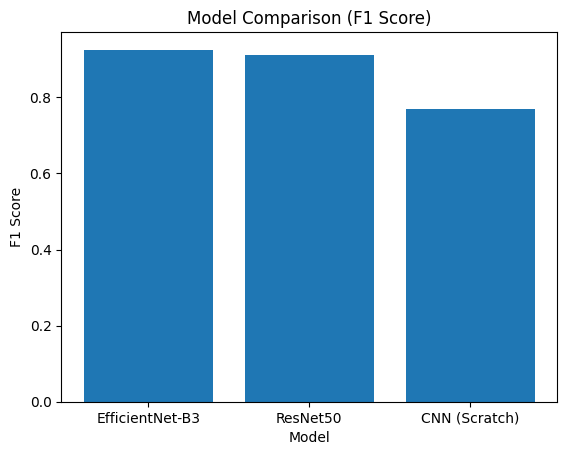

In [142]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["CNN (Scratch)", "EfficientNet-B3", "ResNet50"],
    "F1 Score": [cnn_f1, enet_f1, resnet_f1]
})

comparison = comparison.sort_values("F1 Score", ascending=False)
best_model = comparison.iloc[0]["Model"]
print("Model Performance Comparison:\n")
print(comparison)
print(f"\nBest Model: {best_model} ✅")
plt.figure()
plt.bar(comparison["Model"], comparison["F1 Score"])
plt.title("Model Comparison (F1 Score)")


plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.show()

In [136]:
# import wandb
# wandb.finish()  # reset any broken session

In [137]:
# wandb.login()
# wandb.init(project="23f2004377-t12026", name="final-model-comparison")

# wandb.log({
#     "CNN_F1": cnn_f1,
#     "ENet_F1": enet_f1,
#     "ResNet_F1": resnet_f1
# })

# wandb.finish()

# **6. Ensemble**
Instead of relying on a single model, predictions from multiple models are combined using weighted averaging. This improves overall performance by leveraging the strengths of each model.

In [143]:
print(len(enet_preds), len(resnet_preds))

3020 3020


In [144]:
ids = []
preds = []

for enet_p, resnet_p in zip(enet_preds, resnet_preds):
    scores = 0.6 * enet_p['scores'] + 0.4 * resnet_p['scores']
    scores = np.clip(scores, 1e-6, 1.0)
    
    ids.append(enet_p['id'])
    preds.append(ID2LABEL[int(np.argmax(scores))])

preview_df = pd.DataFrame({
    'id': ids,
    'genre': preds
})

preview_df = preview_df.sort_values('id').reset_index(drop=True)
preview_df.head()

,id,genre
0,1,pop
1,2,classical
2,3,disco
3,4,metal
4,5,country


# **7. Submission**

In [145]:
submission = preview_df.copy().sort_values('id').reset_index(drop=True)

assert submission.shape[1] == 2, "Submission must have exactly 2 columns"
assert set(submission.columns) == {'id', 'genre'}, "Columns must be ['id', 'genre']"
assert submission.isnull().sum().sum() == 0, "Missing values found!"
assert submission['genre'].nunique() > 1, "All predictions are same!"

submission.to_csv('submission.csv', index=False)

print("✅ Submission saved successfully\n")
print("Shape:", submission.shape)

print("\nSample Predictions:")
print(submission.head())

print("\nGenre Distribution:")
print(submission['genre'].value_counts())

✅ Submission saved successfully

Shape: (3020, 2)

Sample Predictions:
   id      genre
0   1        pop
1   2  classical
2   3      disco
3   4      metal
4   5    country

Genre Distribution:
genre
pop          344
reggae       338
metal        322
rock         318
jazz         304
hiphop       290
blues        290
disco        288
classical    273
country      253
Name: count, dtype: int64


## Key Takeaways 
* Spectrograms make a big difference once audio is converted, the problem becomes much closer to image classification
* The CNN trained from scratch works, but clearly struggles compared to pretrained models
* Transfer learning saves time and gives a solid performance boost without heavy tuning
* Multi-crop inference helps stabilize predictions instead of relying on a single segment
* Some genres are harder to separate because they share similar patterns (e.g., rock vs metal, pop vs disco)
* Ensemble works because different models make different mistakes, so combining them reduces overall error
* Model performance depends a lot more on representation (spectrograms) than on complex architecture tweaks
* Even simple weighted averaging (like 60–40) can give noticeable improvements
* Clean preprocessing and consistent input shape matter more than adding complicated augmentations
* Debugging and pipeline consistency (paths, shapes, functions) took more effort than model building itself